# **TP : Les vélos sur le pont de Fremont**

In [1214]:
import pandas as pd
import matplotlib.pyplot as plt

## Chargement du fichier

In [1215]:
local_file = "data/fremont.csv"
data = pd.read_csv(local_file)
data.shape

(175200, 4)

In [1216]:
data.head()

,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,08/01/2022 12:00:00 AM,23.0,7.0,16.0
1,08/01/2022 01:00:00 AM,12.0,5.0,7.0
2,08/01/2022 02:00:00 AM,3.0,0.0,3.0
3,08/01/2022 03:00:00 AM,5.0,2.0,3.0
4,08/01/2022 04:00:00 AM,10.0,2.0,8.0


## Doublons

In [1217]:
data.drop_duplicates(inplace=True)
data.shape

(87600, 4)

## Échauffement : le ```DatetimeIndex```

In [1218]:
sample_dates = pd.to_datetime([
    "2024-01-15 08:00:00",
    "2024-01-20 17:30:00",
    "2024-02-03 12:00:00",
])
print(f"{type(sample_dates)}\n")
print(f"{sample_dates.date}\n")
print(f"{sample_dates.time}\n")
print(f"{sample_dates.dayofweek}\n")
print(f"{sample_dates[sample_dates >= "2024-01-20"]}\n")
print(f"{sample_dates[(sample_dates.year == 2024) & (sample_dates.month == 1)]}")


<class 'pandas.DatetimeIndex'>

[datetime.date(2024, 1, 15) datetime.date(2024, 1, 20)
 datetime.date(2024, 2, 3)]

[datetime.time(8, 0) datetime.time(17, 30) datetime.time(12, 0)]

Index([0, 5, 5], dtype='int32')

DatetimeIndex(['2024-01-20 17:30:00', '2024-02-03 12:00:00'], dtype='datetime64[us]', freq=None)

DatetimeIndex(['2024-01-15 08:00:00', '2024-01-20 17:30:00'], dtype='datetime64[us]', freq=None)


## Parser les dates et renommer les colonnes

In [1219]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 87600 entries, 0 to 87599
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          87600 non-null  str    
 1   Fremont Bridge Total          87586 non-null  float64
 2   Fremont Bridge East Sidewalk  87586 non-null  float64
 3   Fremont Bridge West Sidewalk  87586 non-null  float64
dtypes: float64(3), str(1)
memory usage: 4.5 MB


In [1220]:
data.dtypes

Date                                str
Fremont Bridge Total            float64
Fremont Bridge East Sidewalk    float64
Fremont Bridge West Sidewalk    float64
dtype: object

In [1221]:
data.index = pd.to_datetime(data.Date,format="%m/%d/%Y %I:%M:%S %p")
data.drop(columns="Date",inplace=True)
data.columns = ["Total","West","East"]
data.head()

,Total,West,East
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0


## Données manquantes et extensions types

In [1222]:
data[data["Total"].isna()]

,Total,West,East
Date,,,
2013-03-10 02:00:00,NaN,NaN,NaN
2013-06-14 09:00:00,NaN,NaN,NaN
2013-06-14 10:00:00,NaN,NaN,NaN
2014-03-09 02:00:00,NaN,NaN,NaN
2015-03-08 02:00:00,NaN,NaN,NaN
2015-04-21 11:00:00,NaN,NaN,NaN
2015-04-21 12:00:00,NaN,NaN,NaN
2016-03-13 02:00:00,NaN,NaN,NaN
2017-03-12 02:00:00,NaN,NaN,NaN


In [1223]:
data = data.convert_dtypes(convert_integer=True)
data.head()

,Total,West,East
Date,,,
2022-08-01 00:00:00,23,7,16
2022-08-01 01:00:00,12,5,7
2022-08-01 02:00:00,3,0,3
2022-08-01 03:00:00,5,2,3
2022-08-01 04:00:00,10,2,8


## ```resample()``` : changer la fréquence temporelle

<Axes: xlabel='Date'>

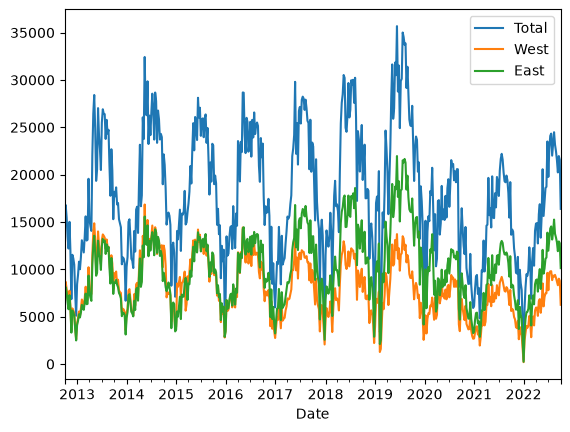

In [1224]:
data.resample("1W").sum().plot()

In [1225]:
print(data.shape)
print(data.resample("1W").sum().shape)

(87600, 3)
(522, 3)


## Découpage temporel

In [1226]:
data = data[data.index.year <= 2017]
data.tail()

,Total,West,East
Date,,,
2017-12-31 19:00:00,21,9,12
2017-12-31 20:00:00,14,6,8
2017-12-31 21:00:00,13,3,10
2017-12-31 22:00:00,13,7,6
2017-12-31 23:00:00,16,7,9


## Évolution annuelle

<Axes: xlabel='Date'>

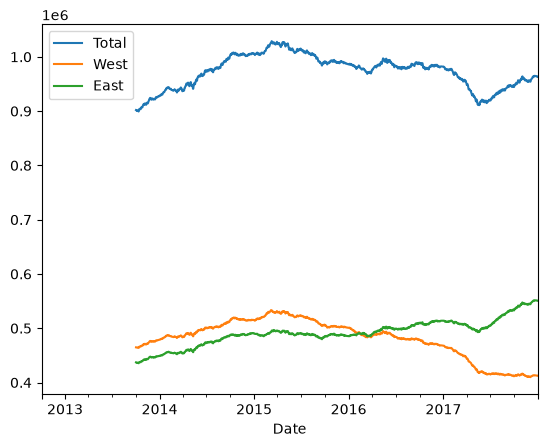

In [1227]:
data.resample("1D").sum().rolling(365).sum().plot()

## Profil journalier moyen

<Axes: xlabel='time'>

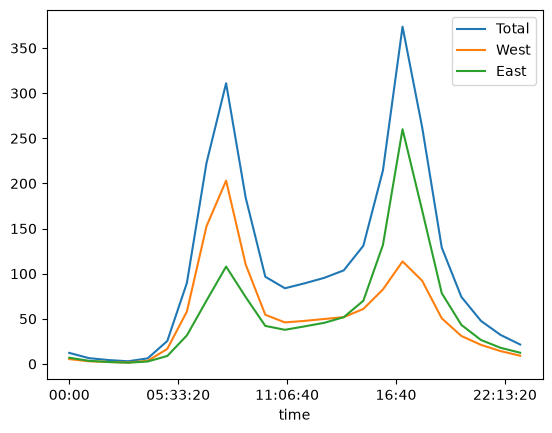

In [1228]:
data.groupby(data.index.time).mean().plot()

## Une courbe par jour : la ```pivot_table```

<Axes: xlabel='time'>

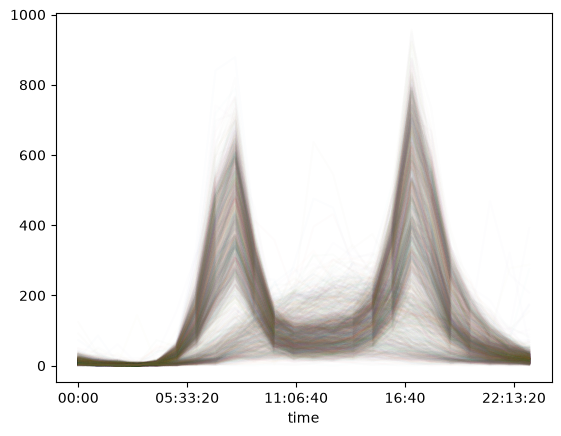

In [1229]:
pivoted = data.pivot_table("Total",index=data.index.time,columns=data.index.date)
pivoted.plot(legend=False,alpha=0.01)

## Classification des jours

### ACP

[[ 327.64078324   -6.76063235]
 [ 251.08260021   36.93578935]
 [ 149.3409454    43.17365982]
 ...
 [-551.91589387 -167.23062779]
 [-603.44893732  -46.56155526]
 [-616.9628518   -33.15205473]]


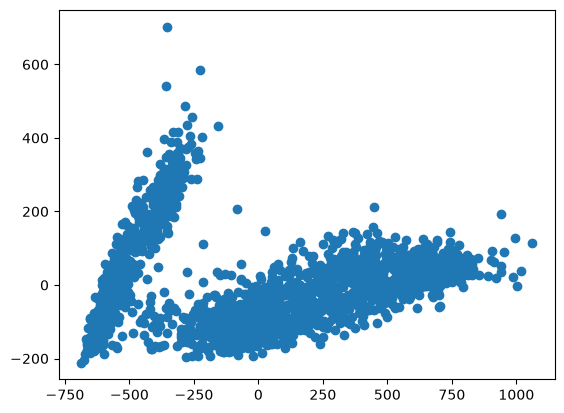

In [1230]:
from sklearn.decomposition import PCA

pca_input = pivoted.T.fillna(0)
pca = PCA(n_components=2).fit_transform(pca_input)
print(pca)
plt.scatter(pca[:,0],pca[:,1])

### ```GaussianMixture```

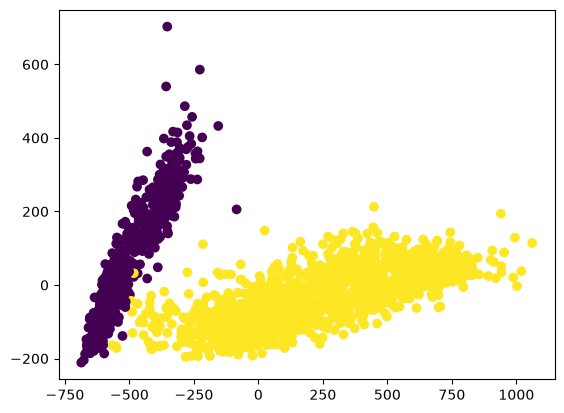

In [1231]:

label = GaussianMixture(n_components=2).fit_predict(pca_input)
plt.scatter(pca[:,0],pca[:,1],c=label)

### Comparons chaque famille aux profils journaliers

<Axes: xlabel='time'>

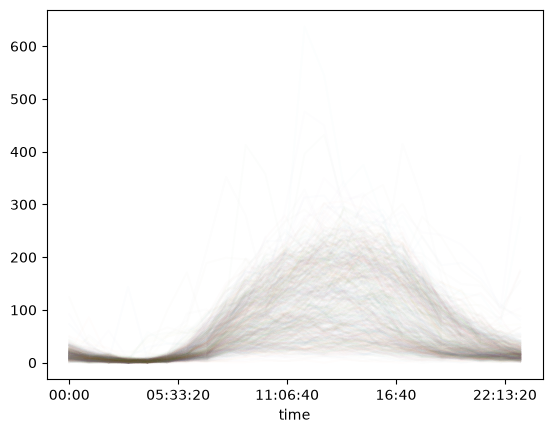

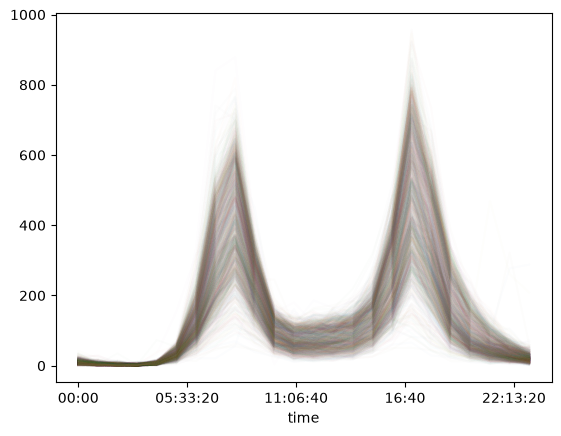

In [1232]:
pivoted.loc[:,label==0].plot(legend=False, alpha=0.01)
pivoted.loc[:,label==1].plot(legend=False, alpha=0.01)

### Vérifions avec le jour de la semaine

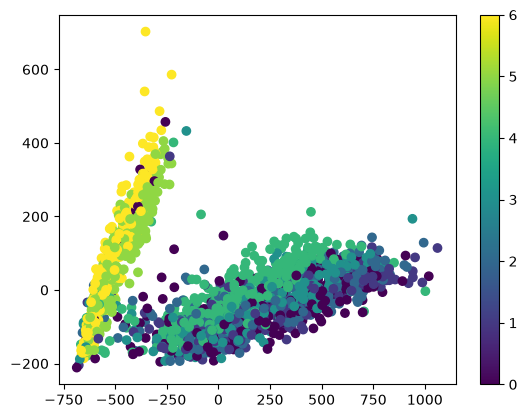

In [1233]:
dates = pd.DatetimeIndex(pivoted.columns)
jour = dates.dayofweek
plt.scatter(pca[:,0],pca[:,1],c=jour)
plt.colorbar()

### Les moutons noirs

,2012-10-03,2012-10-04,2012-10-05,2012-10-08,2012-10-09,2012-10-10,2012-10-11,2012-10-12,2012-10-15,2012-10-16,...,2017-12-14,2017-12-15,2017-12-18,2017-12-19,2017-12-20,2017-12-21,2017-12-22,2017-12-27,2017-12-28,2017-12-29
00:00:00,13.0,18.0,11.0,9.0,12.0,15.0,21.0,17.0,7.0,10.0,...,7.0,9.0,1.0,2.0,7.0,9.0,12.0,4.0,2.0,11.0
01:00:00,10.0,3.0,8.0,4.0,3.0,3.0,10.0,13.0,3.0,5.0,...,4.0,10.0,2.0,2.0,4.0,1.0,0.0,2.0,0.0,2.0
02:00:00,2.0,9.0,7.0,5.0,4.0,3.0,13.0,5.0,5.0,3.0,...,3.0,3.0,1.0,3.0,0.0,3.0,0.0,0.0,2.0,2.0
03:00:00,5.0,3.0,4.0,5.0,8.0,4.0,2.0,7.0,3.0,5.0,...,3.0,4.0,3.0,2.0,4.0,4.0,3.0,1.0,2.0,2.0
04:00:00,7.0,8.0,9.0,5.0,9.0,5.0,12.0,5.0,6.0,5.0,...,3.0,6.0,6.0,8.0,8.0,4.0,6.0,4.0,8.0,5.0
05:00:00,31.0,26.0,25.0,23.0,31.0,25.0,12.0,14.0,26.0,29.0,...,36.0,27.0,20.0,23.0,32.0,28.0,20.0,17.0,21.0,15.0
06:00:00,155.0,142.0,105.0,137.0,153.0,149.0,43.0,87.0,93.0,122.0,...,97.0,62.0,83.0,65.0,87.0,67.0,54.0,42.0,43.0,35.0
07:00:00,352.0,319.0,319.0,327.0,368.0,340.0,304.0,183.0,225.0,256.0,...,253.0,191.0,177.0,132.0,204.0,128.0,102.0,58.0,83.0,56.0
08:00:00,437.0,418.0,370.0,457.0,462.0,435.0,404.0,268.0,327.0,357.0,...,373.0,298.0,278.0,175.0,282.0,239.0,120.0,118.0,117.0,70.0
09:00:00,276.0,241.0,212.0,278.0,275.0,255.0,189.0,145.0,203.0,207.0,...,204.0,154.0,169.0,122.0,163.0,140.0,81.0,63.0,83.0,39.0


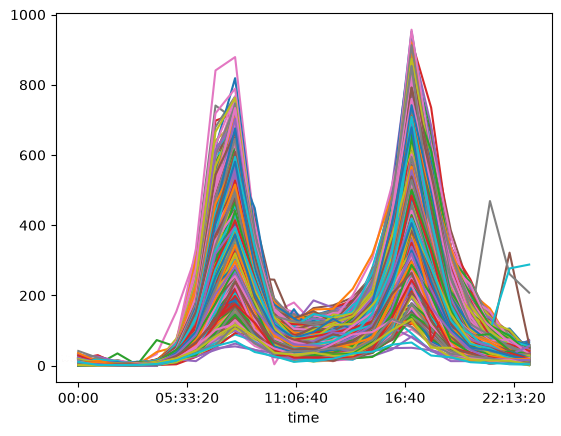

In [1234]:
odd_index = (label==1) & (jour < 5)
pivoted.loc[:,odd_index].plot(legend=False)
odd_dates = dates[odd_index]
pivoted[odd_dates]

## Bonus : k-means, une troisième catégorie de jours ?

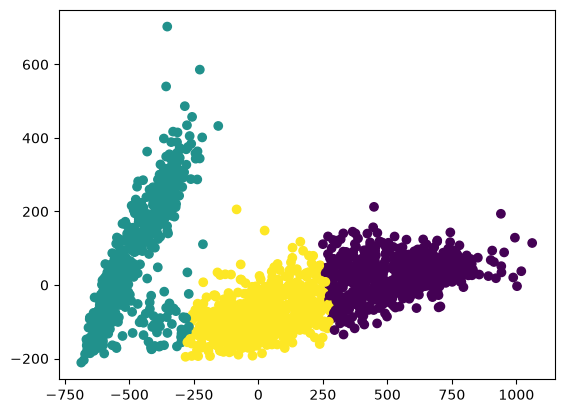

In [1235]:
from sklearn.cluster import KMeans

repartition = KMeans(n_clusters=3,n_init=10).fit_predict(pca_input)
plt.scatter(pca[:,0],pca[:,1],c=repartition)

In [1239]:
day = pd.DatetimeIndex(pca_input.index).dayofweek
pd.crosstab(repartition,day)

col_0,0,1,2,3,4,5,6
row_0,,,,,,,
0,119,129,130,113,82,0,0
1,32,10,12,18,29,274,274
2,122,134,132,143,163,0,0


Le groupe 1 correspond au week-end (et des exceptions).

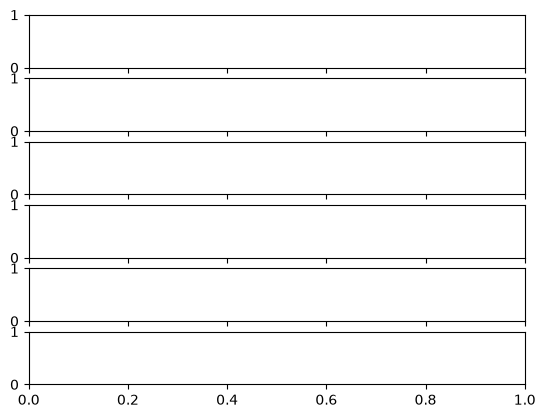

In [1249]:
fig, ax = plt.subplots(6,1,sharex=True)